# Image Captioning con TensorFlow y Flickr8k



Este notebook implementa un sistema de descripción automática de imágenes usando:

- TensorFlow/Keras

- Dataset Flickr8k

- Arquitectura Encoder-Decoder (VGG16 + LSTM)

## Sección 1: Configuración inicial

In [125]:
# Instalación de dependencias (ejecutar solo si es necesario)
#pip install tensorflow numpy matplotlib pillow nltk tqdm requests
#pip install pycocotools


In [13]:
from tqdm import tqdm
import numpy as np
from pathlib import Path
from PIL import Image
from IPython.display import display
import string
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
import datetime
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Concatenate, Dropout, BatchNormalization, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Add
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from pycocotools.coco import COCO
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Gerard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:

import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Descargar todos los recursos necesarios de NLTK
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Sección 2: Descarga y preparación del dataset

In [14]:
class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

def download_file(url, output_path):
    with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=url.split('/')[-1]) as t:
        urllib.request.urlretrieve(url, filename=output_path, reporthook=t.update_to)


In [5]:
#Configuración de rutas (método robusto para Windows)

BASE_DIR = Path(r"C:\Users\Gerard\Desktop\VISUAL_STUDIO\Descrpicion_Automatica_Imagenes")
IMAGE_DIR = BASE_DIR / "Flickr8k" / "Flicker8k_Dataset"
TRAIN_FILE = BASE_DIR / "Flickr8k" / "Flickr_8k.trainImages.txt"
TEST_FILE = BASE_DIR / "Flickr8k" / "Flickr_8k.testImages.txt"
DESCRIPTIONS_FILE = BASE_DIR / "Flickr8k" / "Flickr8k.token.txt"

def load_image_ids_corregido(file_path):
    """Carga IDs eliminando la extensión .jpg"""
    with open(file_path, 'r') as f:
        return [line.strip().split('.')[0] for line in f if line.strip()]

def load_descriptions_corregido(file_path):
    """Carga descripciones normalizando los IDs"""
    descriptions = {}
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            # Maneja ambos formatos: con #0 y sin ello
            if '#' in line:
                img_id = line.split('#')[0].split('.')[0]
            else:
                img_id = line.split('.')[0]
                
            desc = line.split('\t')[1] if '\t' in line else line.split(maxsplit=1)[1]
            
            if img_id not in descriptions:
                descriptions[img_id] = []
            cleaned_desc = desc.lower().translate(str.maketrans('', '', string.punctuation))
            descriptions[img_id].append(cleaned_desc)
    return descriptions

In [6]:
#Verificación de archivos
def verificar_archivos():
    archivos_requeridos = {
        "Directorio de imágenes": IMAGE_DIR,
        "Archivo de train": TRAIN_FILE,
        "Archivo de test": TEST_FILE,
        "Archivo de descripciones": DESCRIPTIONS_FILE
    }
    
    problemas = False
    for nombre, ruta in archivos_requeridos.items():
        if not ruta.exists():
            print(f"❌ {nombre}: NO encontrado en {ruta}")
            problemas = True
        else:
            print(f"✅ {nombre}: encontrado")
            if ruta.is_file() and ruta.stat().st_size == 0:
                print(f"   ⚠️  El archivo está vacío!")
                problemas = True
    
    if problemas:
        raise FileNotFoundError("Faltan archivos requeridos o están vacíos")
    else:
        print("✔ Todos los archivos requeridos están presentes")

verificar_archivos()

✅ Directorio de imágenes: encontrado
✅ Archivo de train: encontrado
✅ Archivo de test: encontrado
✅ Archivo de descripciones: encontrado
✔ Todos los archivos requeridos están presentes


## Sección 3: Carga y preprocesamiento de datos

In [7]:
#Carga de datos
def load_image_ids(file_path):
    if not file_path.exists():
        raise FileNotFoundError(f"Archivo no encontrado: {file_path}")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    if not lines:
        raise ValueError(f"El archivo {file_path} está vacío")
    
    return lines

def load_descriptions(file_path):
    if not file_path.exists():
        raise FileNotFoundError(f"Archivo no encontrado: {file_path}")
    
    descriptions = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            parts = line.split('\t')
            if len(parts) < 2:
                continue
                
            img_id, desc = parts[0], parts[1]
            img_id = img_id.split('.')[0]
            
            if img_id not in descriptions:
                descriptions[img_id] = []
            descriptions[img_id].append(desc.lower().translate(str.maketrans('', '', string.punctuation)))
    
    if not descriptions:
        raise ValueError(f"No se encontraron descripciones válidas en {file_path}")
    
    return descriptions

In [8]:
try:
    train_ids = load_image_ids_corregido(TRAIN_FILE)
    all_descriptions = load_descriptions_corregido(DESCRIPTIONS_FILE)
    
    # Ahora los IDs deberían coincidir
    train_descriptions = {k: all_descriptions[k] for k in train_ids if k in all_descriptions}
    
    print(f"Imágenes de entrenamiento: {len(train_ids)}")
    print(f"Descripciones cargadas: {len(train_descriptions)}")
    print(f"Ejemplo de ID: {list(train_descriptions.keys())[0]}")
    
except Exception as e:
    print(f"Error: {str(e)}")

Imágenes de entrenamiento: 6000
Descripciones cargadas: 6000
Ejemplo de ID: 2513260012_03d33305cf



--EJEMPLO DE IMAGEN Y DESCRIPCION--

Ejemplo para imagen 2513260012_03d33305cf:
a black dog is running after a white dog in the snow 
black dog chasing brown dog through snow
two dogs chase each other across the snowy ground 
two dogs play together in the snow 
two dogs running through a low lying body of water 


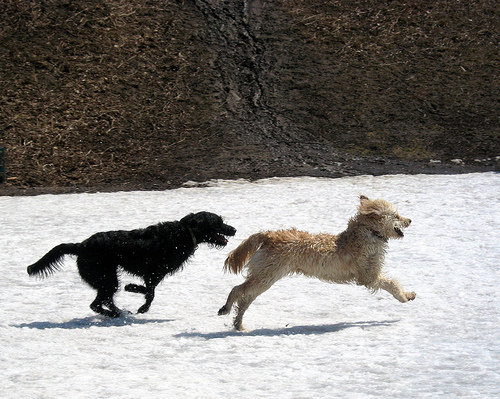

In [9]:
#  Mostrar ejemplo de imagen y descripción
print("\n--EJEMPLO DE IMAGEN Y DESCRIPCION--")

if not train_descriptions:
    print("⚠️ No hay datos de entrenamiento cargados. Verifica los archivos de entrada.")
else:
    sample_img = next(iter(train_descriptions))  # Obtiene la primera clave de forma segura
    
    print(f"\nEjemplo para imagen {sample_img}:")
    print("\n".join(train_descriptions[sample_img]))
    
    img_path = IMAGE_DIR / f"{sample_img}.jpg"
    if not img_path.exists():
        print(f"⚠️ No se encontró la imagen: {img_path}")
        # Verifica posibles variaciones en la extensión
        for ext in ['.jpg', '.JPG', '.jpeg', '.JPEG']:
            alt_path = IMAGE_DIR / f"{sample_img}{ext}"
            if alt_path.exists():
                img_path = alt_path
                break
    
    if img_path.exists():
        try:
            display(Image.open(img_path))
        except Exception as e:
            print(f"Error al abrir la imagen: {str(e)}")
    else:
        print("ℹ️ Posibles soluciones:")
        print(f"1. Verifica que la imagen existe en {IMAGE_DIR}")
        print(f"2. Revisa mayúsculas en la extensión (.jpg vs .JPG)")
        print("3. Comprueba que los IDs en los archivos coincidan con los nombres de las imágenes")

###  3.1 VOCABULARIO

In [10]:
import nltk
import ssl
import os
from tqdm import tqdm
import string
from collections import Counter

# Configuración SSL para descargas
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Descargar recursos NLTK esenciales
try:
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("Recursos NLTK descargados correctamente")
except Exception as e:
    print(f"Error al descargar recursos NLTK: {str(e)}")

Recursos NLTK descargados correctamente


In [11]:
def robust_tokenizer(text, use_nltk=True):
    """Tokenizador con respaldo para cuando falla NLTK"""
    try:
        if use_nltk:
            return nltk.word_tokenize(text.lower())
        else:
            # Alternativa simple sin NLTK
            text = text.lower().translate(str.maketrans('', '', string.punctuation))
            return text.split()
    except:
        # Fallback completo
        return text.lower().split()

In [12]:
def build_vocabulary(descriptions, min_count=5):
    """Crea vocabulario con mejor filtrado y manejo de tokens especiales"""
    word_counts = Counter()
    punctuation = string.punctuation.replace("'", "")  # Mantener apostrofes
    
    print("Construyendo vocabulario...")
    
    # Función de tokenización robusta
    def tokenize_text(text):
        try:
            # Primero intentar con NLTK
            return nltk.word_tokenize(text.lower())
        except:
            # Fallback simple si NLTK falla
            text = text.lower().translate(str.maketrans('', '', punctuation))
            return text.split()
    
    for img_id, desc_list in tqdm(descriptions.items(), desc="Procesando descripciones"):
        for desc in desc_list:
            # Limpieza básica
            desc = desc.lower().strip()
            desc = desc.translate(str.maketrans('', '', punctuation))
            
            # Tokenización
            tokens = tokenize_text(desc)
            
            # Procesamiento adicional de tokens
            processed_tokens = []
            for token in tokens:
                # Manejar contracciones
                if "'" in token and len(token) > 1:
                    parts = token.split("'", 1)
                    processed_tokens.append(parts[0])
                    processed_tokens.append("'" + parts[1])
                else:
                    processed_tokens.append(token)
            
            word_counts.update(processed_tokens)
    
    # Filtrar palabras poco frecuentes y no alfabéticas
    vocabulary = ['<start>', '<end>', '<pad>', '<unk>'] + \
                [word for word, count in word_counts.items() 
                if count >= min_count and word.isalpha()]
    
    print(f"\nVocabulario creado: {len(vocabulary)} palabras")
    print("20 palabras más frecuentes:", word_counts.most_common(20))
    
    return vocabulary

# Crear vocabulario con tamaño mínimo de 3 ocurrencias
try:
    vocabulary = build_vocabulary(train_descriptions, min_count=3)
    vocab_size = len(vocabulary)
    word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}
    idx_to_word = {idx: word for idx, word in enumerate(vocabulary)}
    
    print("\nEjemplos de vocabulario:")
    print("Primeras 10 palabras:", vocabulary[:10])
    print("Últimas 10 palabras:", vocabulary[-10:])
    print("Tamaño del vocabulario:", vocab_size)
except Exception as e:
    print(f"Error al construir el vocabulario: {str(e)}")
    print("ℹ️ Posibles soluciones:")
    print("1. Verifica que NLTK esté correctamente instalado")
    print("2. Asegúrate de haber descargado los recursos con nltk.download()")
    print("3. Revisa que las descripciones estén cargadas correctamente")

Construyendo vocabulario...


Procesando descripciones: 100%|██████████| 6000/6000 [01:07<00:00, 88.31it/s]


Vocabulario creado: 3480 palabras
20 palabras más frecuentes: [('a', 46781), ('in', 14085), ('the', 13509), ('on', 8006), ('is', 6907), ('and', 6672), ('dog', 6159), ('with', 5763), ('man', 5374), ('of', 4967), ('two', 4246), ('white', 2921), ('black', 2854), ('boy', 2634), ('are', 2619), ('woman', 2543), ('girl', 2414), ('to', 2303), ('wearing', 2271), ('at', 2101)]

Ejemplos de vocabulario:
Primeras 10 palabras: ['<start>', '<end>', '<pad>', '<unk>', 'a', 'black', 'dog', 'is', 'running', 'after']
Últimas 10 palabras: ['parrot', 'angels', 'straining', 'ringing', 'hopper', 'trade', 'poem', 'offering', 'toothbrush', 'jeeps']
Tamaño del vocabulario: 3480


In [15]:
# Celda para cargar train_descriptions y test_descriptions correctamente
def load_split_descriptions(all_descriptions, split_file):
    """Carga descripciones para un conjunto específico (train/test)"""
    with open(split_file, 'r') as f:
        split_ids = [line.strip().split('.')[0] for line in f if line.strip()]
    
    return {k: all_descriptions[k] for k in split_ids if k in all_descriptions}

# Cargar TODAS las descripciones primero
all_descriptions = load_descriptions(DESCRIPTIONS_FILE)

# Luego cargar los splits
train_descriptions = load_split_descriptions(all_descriptions, TRAIN_FILE)
test_descriptions = load_split_descriptions(all_descriptions, TEST_FILE)

# Verificación
print(f"\n✔ Train descriptions: {len(train_descriptions)} imágenes")
print(f"✔ Test descriptions: {len(test_descriptions)} imágenes")
print("Ejemplo de test:", list(test_descriptions.items())[0])


✔ Train descriptions: 6000 imágenes
✔ Test descriptions: 1000 imágenes
Ejemplo de test: ('3385593926_d3e9c21170', ['the dogs are in the snow in front of a fence ', 'the dogs play on the snow ', 'two brown dogs playfully fight in the snow ', 'two brown dogs wrestle in the snow ', 'two dogs playing in the snow '])


In [16]:
def preprocess_descriptions(descriptions, word_to_idx):
    """Convierte texto a secuencias de índices"""
    processed = {}
    max_length = 0
    unk_token = word_to_idx['<unk>']
    
    print("\nPreprocesando descripciones...")
    for img_id, desc_list in tqdm(descriptions.items()):
        processed[img_id] = []
        for desc in desc_list:
            words = robust_tokenizer(desc)
            seq = [word_to_idx.get(word, unk_token) for word in words if word in word_to_idx or word.isalnum()]
            if len(seq) > max_length:
                max_length = len(seq)
            processed[img_id].append(seq)
    
    print(f"Longitud máxima de secuencia encontrada: {max_length}")
    return processed, max_length

# Procesar datos
train_descriptions_processed, max_seq_length = preprocess_descriptions(train_descriptions, word_to_idx)
test_descriptions_processed, _ = preprocess_descriptions(test_descriptions, word_to_idx)


Preprocesando descripciones...


100%|██████████| 6000/6000 [01:06<00:00, 90.72it/s]


Longitud máxima de secuencia encontrada: 36

Preprocesando descripciones...


100%|██████████| 1000/1000 [00:10<00:00, 92.15it/s]

Longitud máxima de secuencia encontrada: 31


In [17]:
# Mostrar ejemplo de procesamiento
sample_img = list(train_descriptions_processed.keys())[0]
sample_seq = train_descriptions_processed[sample_img][0]
sample_text = ' '.join([idx_to_word[idx] for idx in sample_seq])

print("\nEjemplo de procesamiento:")
print(f"ID Imagen: {sample_img}")
print(f"Secuencia de índices: {sample_seq}")
print(f"Texto reconstruido: {sample_text}")
print(f"Longitud máxima de secuencia: {max_seq_length}")


Ejemplo de procesamiento:
ID Imagen: 2513260012_03d33305cf
Secuencia de índices: [4, 5, 6, 7, 8, 9, 4, 10, 6, 11, 12, 13]
Texto reconstruido: a black dog is running after a white dog in the snow
Longitud máxima de secuencia: 36


## Sección 4: Preparación del modelo

In [18]:
# Cargar modelo VGG16 preentrenado (Encoder)
def create_encoder():
    vgg = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    vgg.trainable = False
    
    inputs = Input(shape=(224, 224, 3))
    features = vgg(inputs)
    features = tf.keras.layers.GlobalAveragePooling2D()(features)
    
    return Model(inputs, features, name='encoder')

encoder = create_encoder()


In [ ]:
from tensorflow.keras.layers import Layer, Input, Dense, Embedding, LSTM, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras import backend as K

# =============================================
# PRIMERO: DEFINIR TODOS LOS PARÁMETROS REQUERIDOS
# =============================================
VOCAB_SIZE = 5000  # Número de palabras en tu vocabulario
MAX_SEQ_LENGTH = 36  # Longitud máxima de secuencias (ajustar según tus datos)
EMBEDDING_DIM = 128
LSTM_UNITS = 256
DROPOUT_RATE = 0.5
L2_REG = 0.01

# =============================================
# SEGUNDO: DEFINIR LA ARQUITECTURA DEL MODELO
# =============================================
class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units, kernel_regularizer=l2(L2_REG))
        self.W2 = Dense(units, kernel_regularizer=l2(L2_REG))
        self.V = Dense(1, kernel_regularizer=l2(L2_REG))

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# =============================================
# TERCERO: CONSTRUIR EL MODELO
# =============================================
# Entradas
image_input = Input(shape=(512,), name='image_features')
caption_input = Input(shape=(MAX_SEQ_LENGTH,), name='caption_input')

# Capa de imagen
img_features = Dense(EMBEDDING_DIM, activation='relu',
                    kernel_regularizer=l2(L2_REG))(image_input)
img_features = BatchNormalization(momentum=0.9, epsilon=1e-5)(img_features)
img_features = Dropout(DROPOUT_RATE)(img_features)

# Capa de texto
text_embed = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                    mask_zero=False,
                    input_length=MAX_SEQ_LENGTH,
                    embeddings_regularizer=l2(L2_REG))(caption_input)
text_embed = Dropout(0.3)(text_embed)

# Capa LSTM
text_lstm = LSTM(LSTM_UNITS,
                kernel_regularizer=l2(L2_REG),
                recurrent_regularizer=l2(L2_REG),
                dropout=DROPOUT_RATE,
                recurrent_dropout=DROPOUT_RATE,
                return_sequences=True,
                return_state=True,
                implementation=1)

lstm_output, state_h, state_c = text_lstm(text_embed)

# Mecanismo de atención
attention = BahdanauAttention(LSTM_UNITS)
context_vector, attention_weights = attention(lstm_output, img_features)

# Capas finales
combined = Concatenate()([context_vector, img_features])
decoder_output = Dense(LSTM_UNITS, 
                      activation='relu',
                      kernel_regularizer=l2(L2_REG))(combined)
decoder_output = Dropout(DROPOUT_RATE)(decoder_output)
output = Dense(VOCAB_SIZE, 
              activation='softmax',
              kernel_regularizer=l2(L2_REG))(decoder_output)

# Modelo final
decoder = Model(inputs=[image_input, caption_input], outputs=output)

# =============================================
# CUARTO: COMPILAR EL MODELO
# =============================================
optimizer = Adam(
    learning_rate=0.00005,
    clipnorm=0.5,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

def penalized_loss(y_true, y_pred):
    base_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    repeated_penalty = tf.reduce_mean(tf.math.square(y_pred[:, :-1] - y_pred[:, 1:])) * 0.1
    return base_loss + repeated_penalty

decoder.compile(
    optimizer=optimizer,
    loss=penalized_loss,
    metrics=['accuracy']
)

# =============================================
# QUINTO: CALLBACKS
# =============================================
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.01,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Resumen del modelo
decoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_input       │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 36, 128)   │    640,000 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 128)       │     65,664 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 36, 128)   │          0 │ embedding_9[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_38[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ [(None, 36, 256), │    394,240 │ dropout_18[0][0]  │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention… │ [(None, 256),     │     99,073 │ lstm_9[0][0],     │
│ (BahdanauAttention) │ (None, 36, 1)]    │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 384)       │          0 │ bahdanau_attenti… │
│ (Concatenate)       │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 256)       │     98,560 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 256)       │          0 │ dense_42[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 5000)      │  1,285,000 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,583,049 (9.85 MB)

 Trainable params: 2,582,793 (9.85 MB)

 Non-trainable params: 256 (1.00 KB)

## Sección 5: Extracción de características

In [21]:
# Función para preprocesar imágenes para VGG16
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((224, 224))
    img_array = np.array(img)
    
    # Convertir a RGB si es escala de grises
    if len(img_array.shape) == 2:
        img_array = np.stack((img_array,)*3, axis=-1)
    
    # Normalizar para VGG16
    img_array = img_array.astype('float32') / 255.0
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)
    
    return img_array


In [22]:
def load_image_ids(file_path):
    """Carga IDs de imágenes desde archivo"""
    with open(file_path, 'r') as f:
        return [line.strip().split('.')[0] for line in f if line.strip()]

# Cargar IDs para ambos conjuntos
train_ids = load_image_ids(TRAIN_FILE)
test_ids = load_image_ids(TEST_FILE)

print(f"✔ Train IDs cargados: {len(train_ids)}")
print(f"✔ Test IDs cargados: {len(test_ids)}")
print(f"Ejemplo de ID de train: {train_ids[0]}")
print(f"Ejemplo de ID de test: {test_ids[0]}")

✔ Train IDs cargados: 6000
✔ Test IDs cargados: 1000
Ejemplo de ID de train: 2513260012_03d33305cf
Ejemplo de ID de test: 3385593926_d3e9c21170


In [ ]:
# Extraer características de las imágenes
def extract_features(image_ids, encoder, image_dir):
    features = {}
    for img_id in tqdm(image_ids, desc="Extrayendo características"):
        img_path = os.path.join(image_dir, img_id + '.jpg')
        img_array = preprocess_image(img_path)
        img_array = np.expand_dims(img_array, axis=0)
        features[img_id] = encoder.predict(img_array, verbose=0)[0]
    return features


In [27]:
# Extraer características para train y test
train_features = extract_features(train_ids, encoder, IMAGE_DIR)
test_features = extract_features(test_ids, encoder, IMAGE_DIR)

# Guardar características para no tener que extraerlas cada vez
np.save('train_features.npy', train_features)
np.save('test_features.npy', test_features)


Extrayendo características: 100%|██████████| 1000/1000 [04:11<00:00,  3.98it/s]


In [26]:
# Cargar características desde archivos
train_features = np.load('train_features.npy', allow_pickle=True).item()
test_features = np.load('test_features.npy', allow_pickle=True).item()
print(f"✔ Características de entrenamiento cargadas: {len(train_features)} imágenes")

✔ Características de entrenamiento cargadas: 6000 imágenes


## Sección 6: Generador de datos

In [28]:
def data_generator(descriptions, features, word_to_idx, max_length, batch_size=64):
    X1, X2, y = [], [], []
    
    while True:
        for img_id, desc_list in descriptions.items():
            feature = features[img_id]
            
            for desc in desc_list:

                if len(desc) < 2:
                    continue
                    
                for i in range(1, len(desc)):
                    in_seq = pad_sequences([desc[:i]], maxlen=max_length, padding='post')[0]
                    out_word = desc[i]
                    
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_word)
                    
                    if len(X1) == batch_size:
                        yield {'image_features': np.array(X1), 
                            'caption_input': np.array(X2)}, np.array(y)
                        X1, X2, y = [], [], []

## Sección 7: Entrenamiento del modelo

In [29]:
from sklearn.model_selection import train_test_split

# 1. Dividir los IDs de entrenamiento
train_ids, val_ids = train_test_split(
    list(train_descriptions_processed.keys()),
    test_size=0.2,
    random_state=42
)

# 2. Crear subconjuntos
val_descriptions_processed = {k: train_descriptions_processed[k] for k in val_ids}
val_features = {k: train_features[k] for k in val_ids}

# 3. Filtrar train
train_descriptions_processed = {k: train_descriptions_processed[k] for k in train_ids}
train_features = {k: train_features[k] for k in train_ids}

print(f"✔ Train samples: {len(train_ids)}")
print(f"✔ Validation samples: {len(val_ids)}")
print(f"✔ Test samples: {len(test_descriptions_processed)}")

✔ Train samples: 4800
✔ Validation samples: 1200
✔ Test samples: 1000


In [30]:
from sklearn.model_selection import train_test_split

# 1. Dividir los datos en entrenamiento y validación
train_ids, val_ids = train_test_split(
    list(train_descriptions_processed.keys()),
    test_size=0.2,
    random_state=42
)

def create_tf_dataset(descriptions, features, batch_size=128):
    def gen():
        for img_id in descriptions:
            feature = features[img_id]
            for desc in descriptions[img_id]:
                for i in range(1, len(desc)):
                    yield {
                        'image_features': feature,
                        'caption_input': pad_sequences([desc[:i]], maxlen=max_seq_length, padding='post')[0]
                    }, desc[i]
    
    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            {
                'image_features': tf.TensorSpec(shape=(512,), dtype=tf.float32),
                'caption_input': tf.TensorSpec(shape=(max_seq_length,), dtype=tf.int32)
            },
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()

# Crear datasets
train_dataset = create_tf_dataset(train_descriptions_processed, train_features)
val_dataset = create_tf_dataset(val_descriptions_processed, val_features)
test_dataset = create_tf_dataset(test_descriptions_processed, test_features)

# Dividir IDs de entrenamiento/validación
train_ids, val_ids = train_test_split(
    list(train_descriptions_processed.keys()),
    test_size=0.2,
    random_state=42
)


In [ ]:

# Configuración de callbacks
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,  # Aumentado de 5
        min_delta=0.02,  # Más estricto
        mode='max',
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,  # Más bajo
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        save_weights_only=False
    ),
    TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    )
]

In [32]:
# Verificar un batch
sample_batch = next(iter(train_dataset))
print("Claves del batch:", sample_batch[0].keys())
print("Shape image_features:", sample_batch[0]['image_features'].shape)
print("Shape caption_input:", sample_batch[0]['caption_input'].shape)
print("Shape labels:", sample_batch[1].shape)

# Deberías ver:
# Claves del batch: dict_keys(['image_features', 'caption_input'])
# Shape image_features: (64, 512)
# Shape caption_input: (64, max_seq_length)
# Shape labels: (64,)

Claves del batch: dict_keys(['image_features', 'caption_input'])
Shape image_features: (128, 512)
Shape caption_input: (128, 36)
Shape labels: (128,)


In [59]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_attention_model.keras', monitor='val_accuracy', save_best_only=True)
]

BATCH_SIZE = 2048
EPOCHS = 20
train_dataset = train_dataset.repeat() 

history = decoder.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=505,  
    batch_size=BATCH_SIZE,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 108s 206ms/step - accuracy: 0.0226 - loss: 27.0441 - val_accuracy: 0.0969 - val_loss: 14.2370 - learning_rate: 5.0000e-05
Epoch 2/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 106s 210ms/step - accuracy: 0.0849 - loss: 12.6259 - val_accuracy: 0.0971 - val_loss: 9.1910 - learning_rate: 5.0000e-05
Epoch 3/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 104s 205ms/step - accuracy: 0.0876 - loss: 8.6917 - val_accuracy: 0.0971 - val_loss: 7.2910 - learning_rate: 5.0000e-05
Epoch 4/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 106s 210ms/step - accuracy: 0.0903 - loss: 7.1432 - val_accuracy: 0.0971 - val_loss: 6.5288 - learning_rate: 5.0000e-05
Epoch 5/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 104s 206ms/step - accuracy: 0.0905 - loss: 6.5060 - val_accuracy: 0.0971 - val_loss: 6.2073 - learning_rate: 5.0000e-05
Epoch 6/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 101s 199ms/step - accuracy: 0.0940 - loss: 6.1879 - val_accuracy: 0.0971 - val_loss: 6.0555 - learning_rate: 5.0000e-05
Epoch 7/20
505/505 ━━━━━━━━━━━━━━━━━━

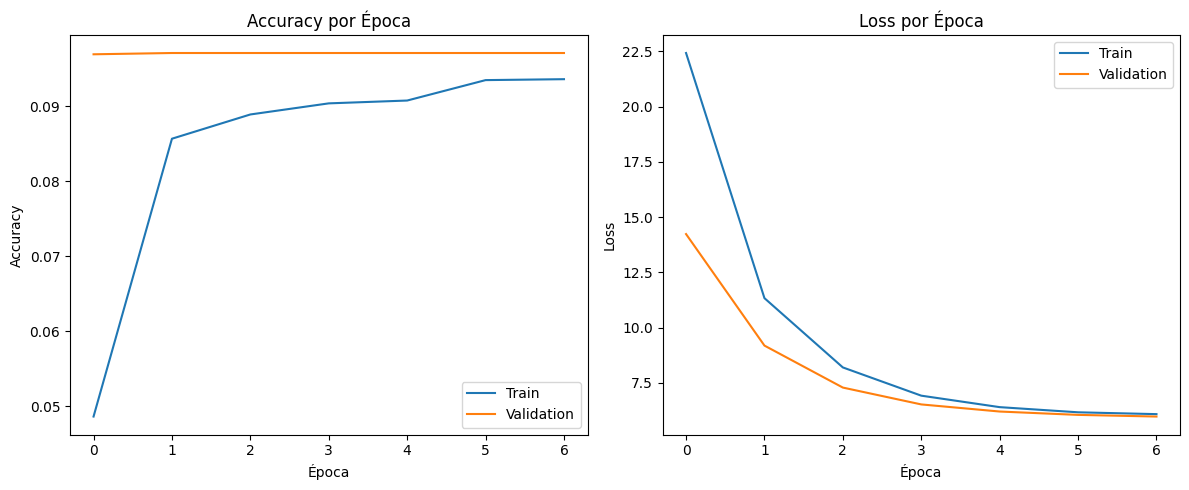

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy por Época')
plt.ylabel('Accuracy')
plt.xlabel('Época')
plt.legend()

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss por Época')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

In [61]:
# Guardar modelo
decoder.save('final_model.keras')

## Sección 8: Generación de descripciones

In [62]:
def preprocess_image(img):
    """Convierte una imagen PIL a array preprocesado para VGG16"""
    img = img.resize((224, 224))
    img_array = np.array(img)
    
    # Convertir a RGB si es escala de grises
    if len(img_array.shape) == 2:
        img_array = np.stack((img_array,)*3, axis=-1)
    
    # Normalizar y preprocesar para VGG16
    img_array = img_array.astype('float32') / 255.0
    return preprocess_input(img_array)

In [63]:
def generate_caption(model, encoder, image_path, word_to_idx, idx_to_word, max_length, beam_size=3, temperature=0.7):
    # Cargar y preprocesar imagen
    img = Image.open(image_path)
    img_array = preprocess_image(img)
    feature = encoder.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
    
    # Beam Search mejorado
    sequences = [[[word_to_idx['<start>']], 1.0]]
    banned_words = set()  # Para evitar repeticiones
    
    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            if seq[-1] == word_to_idx['<end>']:
                all_candidates.append([seq, score])
                continue
                
            padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([np.array([feature]), padded_seq], verbose=0)[0]
            
            # Aplicar temperatura y filtrado
            preds = np.log(preds + 1e-12) / temperature
            exp_preds = np.exp(preds)
            preds = exp_preds / np.sum(exp_preds)
            
            # Evitar palabras repetidas recientemente
            if len(seq) > 1:
                last_word = idx_to_word.get(seq[-1], '')
                if last_word in banned_words:
                    preds[seq[-1]] = 0  # Penalizar repetición
            
            # Tomar las mejores opciones
            top_k = np.argsort(preds)[-beam_size*3:]  # Mayor ventana de selección
            top_k = [i for i in top_k if idx_to_word.get(i, '') not in ['<unk>', '<start>', '<pad>']][:beam_size]
            
            for word_id in top_k:
                new_seq = seq + [word_id]
                new_score = score * preds[word_id]
                
                # Penalizar repeticiones consecutivas
                if len(new_seq) > 2 and new_seq[-1] == new_seq[-2]:
                    new_score *= 0.5
                
                all_candidates.append([new_seq, new_score])
        
        # Ordenar y mantener las mejores secuencias
        ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
        sequences = ordered[:beam_size]
        
        # Actualizar palabras prohibidas
        last_words = [idx_to_word.get(seq[-1], '') for seq, _ in sequences]
        banned_words = set([w for w in last_words if len(w) > 3])  # Solo palabras largas
    
    # Seleccionar mejor secuencia
    best_seq = sequences[0][0]
    
    # Convertir a texto con post-procesamiento
    caption_words = []
    for idx in best_seq:
        word = idx_to_word.get(idx, '')
        if word not in ['<start>', '<end>', '<pad>', '<unk>']:
            caption_words.append(word)
    
    # Eliminar repeticiones consecutivas
    final_words = []
    for i, word in enumerate(caption_words):
        if i == 0 or word != caption_words[i-1]:
            final_words.append(word)
    
    # Unir y capitalizar
    caption = ' '.join(final_words).capitalize()
    
    # Corrección gramatical básica
    if caption.endswith(('a', 'the', 'and')):
        caption = caption.rsplit(' ', 1)[0] + '.'
    elif not caption.endswith(('.', '!', '?')):
        caption += '.'
        
    return caption

Imagen de prueba:


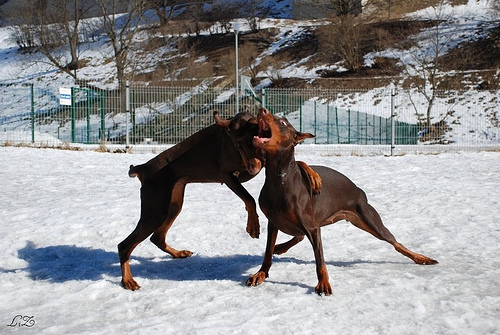


Descripción generada: Is of is of is of is of is of is of is of is of is of is of is of is of is of is of is with man with man with man with.

Descripciones reales:
the dogs are in the snow in front of a fence 
the dogs play on the snow 
two brown dogs playfully fight in the snow 
two brown dogs wrestle in the snow 
two dogs playing in the snow 


In [64]:
# Seleccionar imagen de prueba
test_image_id = list(test_descriptions.keys())[0]
test_image_path = os.path.join(IMAGE_DIR, test_image_id + '.jpg')

# Mostrar imagen
print("Imagen de prueba:")
display(Image.open(test_image_path))

# Generar descripción
caption = generate_caption(decoder, encoder, test_image_path, word_to_idx, idx_to_word, max_seq_length)

# Mostrar resultados
print("\nDescripción generada:", caption)
print("\nDescripciones reales:")
print("\n".join(test_descriptions[test_image_id]))


## Sección 9: Evaluación

In [ ]:
def evaluate_model(model, encoder, test_descriptions, test_features, word_to_idx, idx_to_word, max_length, num_samples=None):
    actual = []
    predicted = []
    
    # Limitar número de muestras si se especifica
    test_items = list(test_descriptions.items())
    if num_samples:
        test_items = test_items[:num_samples]
    
    for img_id, desc_list in tqdm(test_items, desc="Evaluando"):
        img_path = os.path.join(IMAGE_DIR, img_id + '.jpg')
        
        # Generar descripción
        gen_desc = generate_caption(model, encoder, img_path, word_to_idx, idx_to_word, max_length)
        
        # Procesar descripciones reales
        real_descs = [desc.split() for desc in desc_list]
        
        actual.append(real_descs)
        predicted.append(gen_desc.split())
    
    # Calcular BLEU
    smoothie = SmoothingFunction().method4
    bleu1 = corpus_bleu(actual, predicted, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    
    # Calcular CIDEr (requiere formato específico)
    gts = {i: [{'caption': ' '.join(desc)} for desc in desc_list] 
        for i, (img_id, desc_list) in enumerate(test_items)}
    res = {i: [{'caption': ' '.join(pred)}] 
        for i, pred in enumerate(predicted)}
    
    cider_scorer = Cider()
    cider_score, _ = cider_scorer.compute_score(gts, res)
    
    return {
        'BLEU-1': bleu1,
        'BLEU-4': bleu4,
        'CIDEr': cider_score
    }

# Ejemplo de uso:
metrics = evaluate_model(decoder, encoder, test_descriptions, test_features, word_to_idx, idx_to_word, max_seq_length, num_samples=50)
print("\nMétricas de evaluación mejoradas:")
for metric, score in metrics.items():
    print(f"{metric}: {score:.4f}")